In [387]:
import pandas as pd
import numpy as np
import os
import re
import calendar
import matplotlib.pyplot as plt


uploading the original dataset of monthly delays posted on the $\url{https://www.data.gouv.fr/datasets/regularite-mensuelle-tgv-par-liaisons}$ link

In [388]:
file1 = "Data/regularite-mensuelle-tgv-aqst.csv"

In [389]:
df = pd.read_csv(file1, sep=";")

We try to extract dates from the "commentaire à l'arrivée column"

In [390]:
# Étape 1 : Définir le pattern de capture
# Il capture : Jour, Cause, Nb_TGV, Minutes
pattern = r"Le (\d+).*?:\s*(.*?)\s*\((\d+)\s*TGV\s*;\s*(\d+)mn\)"

# Étape 2 : Extraire tous les incidents
# On applique l'extraction sur la colonne des commentaires
extracted = df["Commentaire retards à l'arrivée"].str.extractall(pattern)
extracted.columns = ['Jour_Incident', 'Cause_Incident', 'Nb_TGV_Impactes', 'Minutes_Retard_Cumulees']

# Étape 3 : Préparer la fusion
# Pour n'avoir que l'Index_Original en colonne pour fusionner
extracted = extracted.reset_index(level=1, drop=True).reset_index()

# Étape 4 : La Fusion (Merge)
# On garde toutes les colonnes d'origine (Gares, Date, Prct Retard, etc.)
# Et on crée une ligne par incident extrait
df_final = df.merge(extracted, left_index=True, right_on='index', how='left')

# Étape 5 : Nettoyage
df_final = df_final.drop(columns=['index'])

# Conversion des types pour le calcul
cols_to_fix = ['Jour_Incident', 'Nb_TGV_Impactes', 'Minutes_Retard_Cumulees']
df_final[cols_to_fix] = df_final[cols_to_fix].fillna(0).astype(int)

print(f"Old number of lines : {len(df)}")
print(f"New number of lines: {len(df_final)}")
print(f"Dates extracted: {len(df_final)-len(df)}")

Old number of lines : 11834
New number of lines: 12057
Dates extracted: 223


We observe that very little dates were extracted using this pattern. Exploring further the original csv file we realise that many differernt formats are present in the comment column. We try to update our pattern to reach better extraction. 

In [391]:
import pandas as pd
import re

# Pattern updated
pattern = (
    r"(?:"
    r"[Ll]e\s+(?P<Day_Num>\d+)(?:er)?|" 
    r"(?P<Full_Date_Slash>\d{2}/\d{2})|"
    r"(?P<Date_Text>\d{2}(?:\s+|-)(?:janv|févr|mars|avril|mai|juin|juil|août|sept|oct|nov|déc|juillet)\w*)|"
    r"du\s+(?P<Day_From_Du>\d+)"
    r")"
    r"[\s:]+"
    r"(?:"
        r"\+\s*(?P<min_alt>\d+)\s*[:]\s*" 
    r")?"
    r"(?P<reason>.*?)"
    r"(?:"
        r"\(\s*(?P<tgv>\d+)?\s*[^0-9\)]*(?P<min_std>\d+)\s*(?:min|'|mn)?[^)]*\)" 
        r"|$"
    r")"
)

# Extracting all incidents
extracted = df["Commentaire retards à l'arrivée"].str.extractall(pattern, flags=re.IGNORECASE)

# Handling Merging columns
extracted['Minutes_Retard_Cumulees'] = extracted['min_alt'].fillna(extracted['min_std'])
extracted['Jour_Incident'] = (extracted['Day_Num']
                              .fillna(extracted['Full_Date_Slash'])
                              .fillna(extracted['Date_Text'])
                              .fillna(extracted['Day_From_Du']))

# Cleaning
extracted = extracted.rename(columns={'reason': 'Cause_Incident', 'tgv': 'Nb_TGV_Impactes'})

# Numeric conversion
for col in ['Nb_TGV_Impactes', 'Minutes_Retard_Cumulees']:
    extracted[col] = pd.to_numeric(extracted[col], errors='coerce').fillna(0).astype(int)

# Final column selection
# Use of reset_index() since extractall created multiindexed data MultiIndex (index_original, match_id)
df_final = extracted.reset_index()
df_final = df_final.rename(columns={'level_0': 'index_original'})
df_final = df_final[['index_original', 'Jour_Incident', 'Cause_Incident', 'Nb_TGV_Impactes', 'Minutes_Retard_Cumulees']]

# Merging data using inner join to keep only detected incidents and not Nan
df_merge = df_final.merge(
    df.drop(columns=["Commentaire retards à l'arrivée"]), 
    left_on='index_original', 
    right_index=True, 
    how='inner' 
)

# Final cleaning
df_merge['Cause_Incident'] = df_merge['Cause_Incident'].str.strip()

#Check
print(f" {len(df_merge)} incidents detected")
print(df_merge[['Gare de départ', "Gare d'arrivée",'Jour_Incident', 'Cause_Incident', 'Minutes_Retard_Cumulees']].head(15))

 2348 incidents detected
       Gare de départ      Gare d'arrivée Jour_Incident  \
0             LE MANS  PARIS MONTPARNASSE             1   
1             LE MANS  PARIS MONTPARNASSE             3   
2             LE MANS  PARIS MONTPARNASSE             5   
3             LE MANS  PARIS MONTPARNASSE             7   
4             LE MANS  PARIS MONTPARNASSE            12   
5             LE MANS  PARIS MONTPARNASSE            12   
6             LE MANS  PARIS MONTPARNASSE            17   
7             LE MANS  PARIS MONTPARNASSE            17   
8             LE MANS  PARIS MONTPARNASSE            26   
9   TOULOUSE MATABIAU  PARIS MONTPARNASSE             1   
10  TOULOUSE MATABIAU  PARIS MONTPARNASSE             3   
11  TOULOUSE MATABIAU  PARIS MONTPARNASSE             5   
12  TOULOUSE MATABIAU  PARIS MONTPARNASSE             7   
13  TOULOUSE MATABIAU  PARIS MONTPARNASSE            12   
14  TOULOUSE MATABIAU  PARIS MONTPARNASSE            17   

                              

In [392]:
out_path = 'Data/retards_extraits.csv'
df_merge.to_csv(out_path, index=False)

Now that our extraction was way more performing, we add these new dates to our orignal data file.

In [393]:
#We prepare the extracted incidents
df_extracted = extracted.reset_index().rename(columns={'level_0': 'index_original'})

df_clean_incidents = df_extracted[[
    'index_original', 'Jour_Incident', 'Cause_Incident', 
    'Nb_TGV_Impactes', 'Minutes_Retard_Cumulees'
]]

#Merging starting from 'df' (original data file) as left_index=True and 'right_on=index_original' for the extracted incidents file
# use how='left' to guarantee we kkeep all orignal data even without delay extracted
df_final_complet = df.merge(
    df_clean_incidents, 
    left_index=True, 
    right_on='index_original', 
    how='left' 
)

#Cleaning - filling in empty columns with neutral values
df_final_complet['Cause_Incident'] = df_final_complet['Cause_Incident'].fillna("Aucun incident majeur répertorié")
df_final_complet['Minutes_Retard_Cumulees'] = df_final_complet['Minutes_Retard_Cumulees'].fillna(0).astype(int)

#Final check 
print(f"Final number of rows: {len(df_final_complet)}") 
#Should be >= 11834

print(df_final_complet[['Gare de départ', 'Gare d\'arrivée', 'Cause_Incident']].head(10))

Final number of rows: 13837
       Gare de départ      Gare d'arrivée  \
NaN  BORDEAUX ST JEAN  PARIS MONTPARNASSE   
0.0           LE MANS  PARIS MONTPARNASSE   
1.0           LE MANS  PARIS MONTPARNASSE   
2.0           LE MANS  PARIS MONTPARNASSE   
3.0           LE MANS  PARIS MONTPARNASSE   
4.0           LE MANS  PARIS MONTPARNASSE   
5.0           LE MANS  PARIS MONTPARNASSE   
6.0           LE MANS  PARIS MONTPARNASSE   
7.0           LE MANS  PARIS MONTPARNASSE   
8.0           LE MANS  PARIS MONTPARNASSE   

                                        Cause_Incident  
NaN                   Aucun incident majeur répertorié  
0.0          Tempête Carmen sur la façade Atlantique    
1.0          Tempête Eleonor sur l’ouest de la France   
2.0   Dérangement d’une aiguille en gare de Massy TGV   
3.0  Dérangement du poste d’aiguillage de Paris Mon...  
4.0       Colis suspect en gare de Paris Montparnasse   
5.0              Incident caténaire en gare de Rennes   
6.0  Dérangement du 

In [394]:
df_final_complet

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",index_original,Jour_Incident,Cause_Incident,Nb_TGV_Impactes,Minutes_Retard_Cumulees
NaN,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,31.092437,10.924370,15.966387,5.042017,0.840336,0,NaN,Aucun incident majeur répertorié,NaN,0
0.0,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,35.000000,16.666667,16.666667,8.333333,3.333333,1,1,Tempête Carmen sur la façade Atlantique,52.0,1079
1.0,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,35.000000,16.666667,16.666667,8.333333,3.333333,1,3,Tempête Eleonor sur l’ouest de la France,35.0,407
2.0,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,35.000000,16.666667,16.666667,8.333333,3.333333,1,5,Dérangement d’une aiguille en gare de Massy TGV,57.0,1254
3.0,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,35.000000,16.666667,16.666667,8.333333,3.333333,1,7,Dérangement du poste d’aiguillage de Paris Mon...,70.0,1490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,2025-12,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,175,215,0,NaN,21,21.987302,...,13.793103,20.689655,20.689655,6.896552,3.448276,11829,NaN,Aucun incident majeur répertorié,NaN,0
NaN,2025-12,National,PARIS MONTPARNASSE,VANNES,154,272,1,NaN,47,21.710638,...,16.666667,19.047619,45.238095,4.761905,4.761905,11830,NaN,Aucun incident majeur répertorié,NaN,0
NaN,2025-12,National,POITIERS,PARIS MONTPARNASSE,95,442,0,NaN,190,10.436053,...,23.255814,27.906977,18.604651,3.488372,16.279070,11831,NaN,Aucun incident majeur répertorié,NaN,0
NaN,2025-12,National,RENNES,PARIS MONTPARNASSE,98,791,3,NaN,314,8.905945,...,32.939985,28.327076,9.756243,6.031349,7.568985,11832,NaN,Aucun incident majeur répertorié,NaN,0


In [395]:
df_final_complet.to_csv("Data/sncf_retards_complet.csv", index=False, encoding='utf-8-sig')
print("File saved")

File saved


We now have a CSV that regroups original data and the data we managed to extract. We want to reorganize our CSV in order to have the following new columns:
- Année - the year of the incident
- Mois - the month of the incident
- Jour - the day of the inicident
- Date complète - the day of the incident



In [396]:
#Preparing columns Année and Mois thanks to the Date columnin the following format (year-month)
df_final_complet[['Annee', 'Mois']] = df_final_complet['Date'].str.split('-', expand=True)

#Extracting the days
def extraire_jour_unique(valeur):
    if pd.isna(valeur) or valeur == "Aucun":
        return None
    match = re.search(r'(\d+)', str(valeur))
    if match:
        return int(match.group(1))
    return None

df_final_complet['Jour'] = df_final_complet['Jour_Incident'].apply(extraire_jour_unique)

#Créating Date_Accident column
def creer_date_si_possible(row):
    if pd.isna(row['Jour']):
        return pd.NaT  #Unknown days reported as NaT
    try:
        return pd.to_datetime(f"{row['Annee']}-{row['Mois']}-{int(row['Jour'])}", format='%Y-%m-%d')
    except:
        return pd.NaT #Impossible dates reported as NaT
df_final_complet['Date_Accident'] = df_final_complet.apply(creer_date_si_possible, axis=1)

# Final organisation of columns
cols_ordonnees = ['Annee', 'Mois', 'Jour', 'Date_Accident', 'Gare de départ', 'Cause_Incident', 'Minutes_Retard_Cumulees']
#Merging with other columns
autres_cols = [c for c in df_final_complet.columns if c not in cols_ordonnees]
df_final_complet = df_final_complet[cols_ordonnees + autres_cols]

#Saving
#df_final_complet.to_csv("Data/sncf_analyse_propre.csv", index=False, encoding='utf-8-sig')

print("3 column structure: NaN day if not found, NaT date if not found")
print(df_final_complet[['Annee', 'Mois', 'Jour', 'Date_Accident']].head(15))

3 column structure: NaN day if not found, NaT date if not found
    Annee Mois  Jour Date_Accident
NaN  2018   01   NaN           NaT
0.0  2018   01   1.0    2018-01-01
1.0  2018   01   3.0    2018-01-03
2.0  2018   01   5.0    2018-01-05
3.0  2018   01   7.0    2018-01-07
4.0  2018   01  12.0    2018-01-12
5.0  2018   01  12.0    2018-01-12
6.0  2018   01  17.0    2018-01-17
7.0  2018   01  17.0    2018-01-17
8.0  2018   01  26.0    2018-01-26
NaN  2018   01   NaN           NaT
NaN  2018   01   NaN           NaT
NaN  2018   01   NaN           NaT
NaN  2018   01   NaN           NaT
9.0  2018   01   1.0    2018-01-01


Therefore, all the trains for which we have extracted a delay should have a value in the day column as well as in the date one. 

In [397]:
df_jour=df_final_complet.dropna(subset=['Jour'])

In [398]:
len(df_jour)

2348

In [399]:
df_date = df_jour[df_jour['Date_Accident'].isna()]

In [400]:
df_date

,Annee,Mois,Jour,Date_Accident,Gare de départ,Cause_Incident,Minutes_Retard_Cumulees,Date,Service,Gare d'arrivée,...,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",index_original,Jour_Incident,Nb_TGV_Impactes
15.0,2018,01,9760.0,NaT,GRENOBLE,heurte un chevreuil vers Le-Creusot-Montchanin...,0,2018-01,National,PARIS LYON,...,6,17.647059,52.941176,0.000000,23.529412,5.882353,0.000000,15,9760,0.0
74.0,2018,01,6806.0,NaT,MARNE LA VALLEE,7819 du 6 +66: Dérangement d'installations,25,2018-01,National,LYON PART DIEU,...,17,31.250000,31.250000,12.500000,18.750000,6.250000,0.000000,63,6806,0.0
569.0,2018,02,2706.0,NaT,PARIS EST,Aucun incident majeur répertorié,7,2018-02,National,STRASBOURG,...,11,56.521739,4.347826,5.434783,29.347826,4.347826,0.000000,235,2706,0.0
731.0,2018,06,9827.0,NaT,PARIS LYON,à Valence-TGV,0,2018-06,National,AVIGNON TGV,...,13,11.111111,24.074074,19.444444,30.555556,12.962963,1.851852,671,9827,0.0
749.0,2018,06,7699.0,NaT,PARIS EST,? 2501,0,2018-06,National,NANCY,...,5,12.500000,25.000000,3.125000,37.500000,21.875000,0.000000,761,7699,2.0
775.0,2018,06,9827.0,NaT,PARIS LYON,à Valence-TGV,0,2018-06,National,TOULON,...,6,23.684211,36.842105,5.263158,28.947368,2.631579,2.631579,771,9827,0.0
776.0,2018,06,9827.0,NaT,TOULON,à Valence-TGV,0,2018-06,National,PARIS LYON,...,7,22.500000,47.500000,2.500000,17.500000,5.000000,5.000000,772,9827,0.0
780.0,2018,07,6627.0,NaT,PARIS LYON,"à Maisons-Alfort, suivi de 4 alertes radio pou...",0,2018-07,National,BELLEGARDE (AIN),...,13,79.518072,13.253012,3.614458,3.614458,0.000000,0.000000,790,6627,0.0
798.0,2018,07,6627.0,NaT,PARIS LYON,"à Maisons-Alfort, suivi de 4 alertes radio pou...",0,2018-07,National,AVIGNON TGV,...,19,14.102564,14.743590,26.923077,38.461538,5.769231,0.000000,814,6627,0.0
799.0,2018,07,6627.0,NaT,AVIGNON TGV,"à Maisons-Alfort, suivi de 4 alertes radio pou...",0,2018-07,National,PARIS LYON,...,25,18.055556,25.925926,31.944444,15.277778,3.703704,5.092593,815,6627,0.0


In [401]:
df_date["Commentaire retards à l'arrivée"]

15.0      Le 9760 heurte un chevreuil vers Le-Creusot-Mo...
74.0      7808 du 10 + 39: Attente client à MSC du 6806\...
569.0     04/04 : 2465? Obstacle à la fermeture des port...
731.0     intervention pompiers à bord du 9827 à Valence...
749.0     01/06 : Attente matériel du 2546 pour 2519 (36...
775.0     intervention pompiers à bord du 9827 à Valence...
776.0     intervention pompiers à bord du 9827 à Valence...
780.0     •accident de personne avec le 6627 à Maisons-A...
798.0     •accident de personne avec le 6627 à Maisons-A...
799.0     •accident de personne avec le 6627 à Maisons-A...
828.0     le domaine « extérieur infra » pour l’irrégula...
829.0     problème de traction du 9582 vers Aix-en-Prove...
870.0     le domaine « extérieur infra » pour l’irrégula...
871.0     problème de traction du 9582 vers Aix-en-Prove...
912.0     •accident de personne avec le 6627 à Maisons-A...
938.0     •accident de personne avec le 6627 à Maisons-A...
939.0     •problème de traction du 9582 

45 lines of the trains with extracted delays have instead of their day date what seems to be their train number. If we verify through the written comments, we can most often identify that the train number was inserted instead. We could either try to manually resolve the 45 issues or change the pattern learned above. Since the format in which the comments of these 45 errors are written varry a lot, we choose to observe these lines more closely. We realise most of these have already been taken into account and it is when trying to count them once again that we reach an error. We therefore make the choice to simply disregard these rows which are quite insignificant since they are only 45/2348 - not even 2%.

In [402]:
df_date_indexed = df_date.reset_index(drop=True)
print(df_date_indexed.loc[10, "Commentaire retards à l'arrivée"])

le domaine « extérieur infra » pour l’irrégularité a atteint un sommet avec quasiment 7 points, on relève deux accidents de personne en début de mois : d’une part sur le secteur Nord à Hattencourt (mercredi 04) et le secteur Sud est à Lyon Part Dieu (jeudi 05) d’autre part. Pour l’évènement d’Hattencourt avec l’Eurostar 9031, la circulation normale des trains a repris après 05h30 d’interruption totale. Pour ce même domaine côté infra il s’agit de multiples causes d’incendies ou orages violents dans le Sud Est.
Les causes dérangements sont aussi nombreuses (4,7%) , avec en évènements marquants les défauts de géométrie de voie (passage rame contrôle IRIS) et surtout les dérangements d’installations de signalisation (zones, aiguilles, etc.).
Le Matériel prend une part importante pour l’irrégularité avec 5,2 points. Plusieurs fois le motif « tension parc » a été relevé avec des retards plus ou moins importants, voire des suppressions de trains. Les chantiers du Landy et Forest ont peiné à 

In [403]:
# Keeps only the indices in dd that are not in df_date
df_jour = df_jour.drop(df_date.index, errors='ignore')

In [404]:
df_jour

,Annee,Mois,Jour,Date_Accident,Gare de départ,Cause_Incident,Minutes_Retard_Cumulees,Date,Service,Gare d'arrivée,...,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",index_original,Jour_Incident,Nb_TGV_Impactes
0.0,2018,01,1.0,2018-01-01,LE MANS,Tempête Carmen sur la façade Atlantique,1079,2018-01,National,PARIS MONTPARNASSE,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,1,52.0
1.0,2018,01,3.0,2018-01-03,LE MANS,Tempête Eleonor sur l’ouest de la France,407,2018-01,National,PARIS MONTPARNASSE,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,3,35.0
2.0,2018,01,5.0,2018-01-05,LE MANS,Dérangement d’une aiguille en gare de Massy TGV,1254,2018-01,National,PARIS MONTPARNASSE,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,5,57.0
3.0,2018,01,7.0,2018-01-07,LE MANS,Dérangement du poste d’aiguillage de Paris Mon...,1490,2018-01,National,PARIS MONTPARNASSE,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,7,70.0
4.0,2018,01,12.0,2018-01-12,LE MANS,Colis suspect en gare de Paris Montparnasse,499,2018-01,National,PARIS MONTPARNASSE,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,12,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343.0,2019,07,3.0,2019-07-03,RENNES,un bagage abandonné dans un TGV impose un arrê...,256,2019-07,National,LYON PART DIEU,...,5,5.882353,23.529412,29.411765,29.411765,5.882353,5.882353,2409,3,26.0
2344.0,2019,07,9.0,2019-07-09,RENNES,une détection de chute de pierre déclenche les...,886,2019-07,National,LYON PART DIEU,...,5,5.882353,23.529412,29.411765,29.411765,5.882353,5.882353,2409,9,12.0
2345.0,2019,07,15.0,2019-07-15,RENNES,un heurt de chevreuil sur la ligne à grande vi...,1009,2019-07,National,LYON PART DIEU,...,5,5.882353,23.529412,29.411765,29.411765,5.882353,5.882353,2409,15,25.0
2346.0,2019,07,25.0,2019-07-25,RENNES,un incendie aux abords des voies sur la ligne ...,1203,2019-07,National,LYON PART DIEU,...,5,5.882353,23.529412,29.411765,29.411765,5.882353,5.882353,2409,25,42.0


In [405]:
df_final_complet.to_csv("Data/sncf_retards_complet.csv", index=False, encoding='utf-8-sig')
print("File saved")

File saved


In [406]:
df_final_complet.columns

Index(['Annee', 'Mois', 'Jour', 'Date_Accident', 'Gare de départ',
       'Cause_Incident', 'Minutes_Retard_Cumulees', 'Date', 'Service',
       'Gare d'arrivée', 'Durée moyenne du trajet',
       'Nombre de circulations prévues', 'Nombre de trains annulés',
       'Commentaire annulations', 'Nombre de trains en retard au départ',
       'Retard moyen des trains en retard au départ',
       'Retard moyen de tous les trains au départ',
       'Commentaire retards au départ',
       'Nombre de trains en retard à l'arrivée',
       'Retard moyen des trains en retard à l'arrivée',
       'Retard moyen de tous les trains à l'arrivée',
       'Commentaire retards à l'arrivée', 'Nombre trains en retard > 15min',
       'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)',
       'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min',
       'Prct retard pour causes externes',
       'Prct retard pour cause infrastructure',
       'Prct retard pour cause gestion

# Adding rows for daily trains with delays not extracted
Since we work with daily delays but our data is regrouped in monthly batches, we need to create rows for each day and each journey

In [407]:
df = pd.read_csv('Data/sncf_retards_complet.csv')
df['retard moyen'] = df['Minutes_Retard_Cumulees']/df['Nb_TGV_Impactes']

In [408]:
df.shape

(13837, 36)

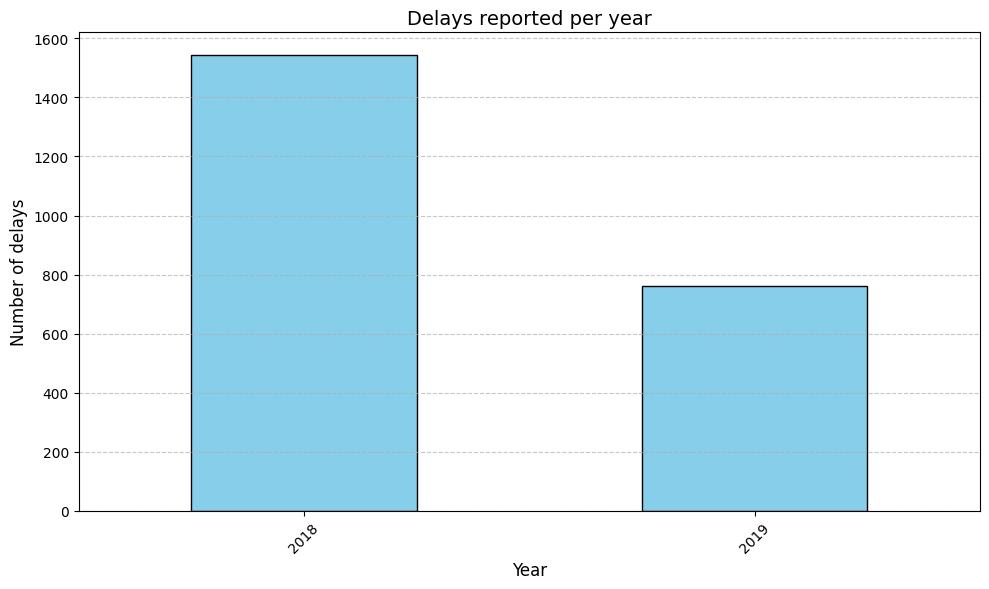

In [409]:
df_to_plot = df.dropna(subset='Date_Accident')

counts = df_to_plot['Annee'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Delays reported per year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of delays', fontsize=12)

# Rotation des étiquettes de l'axe X pour une meilleure lisibilité
plt.xticks(rotation=45)

# Ajout d'une grille horizontale pour faciliter la lecture des valeurs
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajustement pour éviter que les étiquettes ne soient tronquées
plt.tight_layout()

We also realise that all the extracted comments are from 2018 and 2019 therefore we delete all the other years.

In [410]:
years_to_delete = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

# Le symbole ~ signifie "NOT" (l'inverse de la condition)
df = df[~df['Annee'].isin(years_to_delete)]

In [411]:
print(f"Dataset original : {df.shape[0]} lignes")

# We differentiate incident dates that were found and not
incidents = df[df['Jour'].notna()].copy()
summary   = df[df['Jour'].isna()].copy()

LIAISON_KEY = [
    'Gare de départ', 'Annee', 'Mois',
    'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)',
    'Nombre trains en retard > 15min'
]

new_rows = []

# Retrieve the know journeys with delays (daily or monthly)
# We also group those without 'Retard moyen' and 'Nombre trains' to get months without any delays recorded
LIAISON_KEY_BASE = ['Gare de départ', 'Annee', 'Mois']

all_months = df[LIAISON_KEY_BASE + [
    "Retard moyen de tous les trains à l'arrivée",
    'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)',
    'Nombre trains en retard > 15min'
]].drop_duplicates(subset=LIAISON_KEY_BASE)

for _, month_row in all_months.iterrows():
    gare        = month_row['Gare de départ']
    annee       = month_row['Annee']
    mois        = month_row['Mois']
    retard_tous = month_row["Retard moyen de tous les trains à l'arrivée"]  

    if pd.isna(retard_tous):
        continue

    nb_jours_mois = calendar.monthrange(int(annee), int(mois))[1]

    group = incidents[
        (incidents['Gare de départ'] == gare) &
        (incidents['Annee'] == annee) &
        (incidents['Mois'] == mois)
    ]

    if len(group) > 0:
        daily_stats            = group.groupby('Jour')['retard moyen'].mean()
        somme_retard_connue    = daily_stats.sum()
        nb_jours_avec_incident = daily_stats.count()
        denom                  = nb_jours_mois - nb_jours_avec_incident

        if denom <= 0:
            continue

        budget_restant = (retard_tous * nb_jours_mois) - somme_retard_connue
        fill_value     = max(0.0, budget_restant / denom)

        days_present = set(daily_stats.index.astype(int).tolist())
        missing_days = set(range(1, nb_jours_mois + 1)) - days_present
        template     = group.iloc[0].copy()

    else:
        fill_value   = float(retard_tous)
        missing_days = set(range(1, nb_jours_mois + 1))

        template_rows = df[
            (df['Gare de départ'] == gare) &
            (df['Annee'] == annee) &
            (df['Mois'] == mois) &
            (df['Jour'].isna())
        ]
        if len(template_rows) == 0:
            continue
        template = template_rows.iloc[0].copy()

    for day in sorted(missing_days):
        row = template.copy()
        row['Jour']                             = float(day)
        row['Date_Accident']                    = f'{int(annee)}-{int(mois):02d}-{day:02d}'
        row['retard moyen']                     = round(fill_value, 6)
        row['Minutes_Retard_Cumulees']          = 0
        row['Cause_Incident']                   = 'Aucun incident majeur répertorié'
        row['Nb_TGV_Impactes']                  = np.nan
        row["Commentaire retards à l'arrivée"]  = np.nan
        new_rows.append(row)
df_enrich = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)


#saving
out_path = 'Data/sncf_avecetsans.csv'
df_enrich.to_csv(out_path, index=False)

print(f"  Lignes originales  : {df.shape[0]}")
print(f"  Nouvelles lignes   : {len(new_rows)}")
print(f"  Total              : {df_enrich.shape[0]}")

Dataset original : 5039 lignes
  Lignes originales  : 5039
  Nouvelles lignes   : 41017
  Total              : 46056


In [412]:
# On garde tout ce qui n'est pas "0"
df = df[(df['Gare de départ'] != '0') & (df["Gare d'arrivée"] != '0')]

In [413]:
display(df_enrich)

,Annee,Mois,Jour,Date_Accident,Gare de départ,Cause_Incident,Minutes_Retard_Cumulees,Date,Service,Gare d'arrivée,...,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",index_original,Jour_Incident,Nb_TGV_Impactes,retard moyen
0,2018,1,NaN,NaN,BORDEAUX ST JEAN,Aucun incident majeur répertorié,0,2018-01,National,PARIS MONTPARNASSE,...,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,0,NaN,NaN,NaN
1,2018,1,1.0,2018-01-01,LE MANS,Tempête Carmen sur la façade Atlantique,1079,2018-01,National,PARIS MONTPARNASSE,...,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,1,52.0,20.750000
2,2018,1,3.0,2018-01-03,LE MANS,Tempête Eleonor sur l’ouest de la France,407,2018-01,National,PARIS MONTPARNASSE,...,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,3,35.0,11.628571
3,2018,1,5.0,2018-01-05,LE MANS,Dérangement d’une aiguille en gare de Massy TGV,1254,2018-01,National,PARIS MONTPARNASSE,...,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,5,57.0,22.000000
4,2018,1,7.0,2018-01-07,LE MANS,Dérangement du poste d’aiguillage de Paris Mon...,1490,2018-01,National,PARIS MONTPARNASSE,...,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,1,7,70.0,21.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46051,2019,12,27.0,2019-12-27,ZURICH,Aucun incident majeur répertorié,0,2019-12,International,PARIS LYON,...,77.272727,0.000000,13.636364,0.000000,4.545455,4.545455,3034,NaN,NaN,6.058069
46052,2019,12,28.0,2019-12-28,ZURICH,Aucun incident majeur répertorié,0,2019-12,International,PARIS LYON,...,77.272727,0.000000,13.636364,0.000000,4.545455,4.545455,3034,NaN,NaN,6.058069
46053,2019,12,29.0,2019-12-29,ZURICH,Aucun incident majeur répertorié,0,2019-12,International,PARIS LYON,...,77.272727,0.000000,13.636364,0.000000,4.545455,4.545455,3034,NaN,NaN,6.058069
46054,2019,12,30.0,2019-12-30,ZURICH,Aucun incident majeur répertorié,0,2019-12,International,PARIS LYON,...,77.272727,0.000000,13.636364,0.000000,4.545455,4.545455,3034,NaN,NaN,6.058069


In [414]:
# Extraction des trajets uniques
trajets_uniques = df_enrich[['Gare de départ', "Gare d'arrivée"]].drop_duplicates()

# Tri par gare de départ pour plus de clarté
trajets_uniques = trajets_uniques.sort_values(by='Gare de départ')

print(f"There exists {len(trajets_uniques)} different journeys.")
print(trajets_uniques)

There exists 130 different journeys.
          Gare de départ      Gare d'arrivée
26   AIX EN PROVENCE TGV          PARIS LYON
180    ANGERS SAINT LAUD  PARIS MONTPARNASSE
133            ANGOULEME  PARIS MONTPARNASSE
27                ANNECY          PARIS LYON
192                ARRAS          PARIS NORD
..                   ...                 ...
198            TOURCOING    BORDEAUX ST JEAN
59                 TOURS  PARIS MONTPARNASSE
74    VALENCE ALIXAN TGV          PARIS LYON
20                VANNES  PARIS MONTPARNASSE
217               ZURICH          PARIS LYON

[130 rows x 2 columns]


# Adding external factors to the dataset

We now need to create the data set that gathers vacations, concerts and sports events in order to continue with our analysis. 

In [415]:
def load_data(path):
    """Loads the dataset."""
    return pd.read_csv(path)

def clean_concert_data(df):
    french_to_eng = {
        'janvier': 'Jan', 'janv': 'Jan', 'février': 'Feb', 'févr': 'Feb', 'fév': 'Feb',
        'mars': 'Mar', 'mar':'Mar', 'avril': 'Apr', 'avr': 'Apr', 'mai': 'May', 'juin': 'Jun',
        'juillet': 'Jul', 'juil': 'Jul', 'juill':'Jul', 'août': 'Aug', 'septembre': 'Sep', 
        'sept': 'Sep', 'octobre': 'Oct', 'oct': 'Oct', 'novembre': 'Nov', 
        'nov': 'Nov', 'décembre': 'Dec', 'déc': 'Dec'
    }



    df = df.copy()

    #Dealing with the date
    def _parse_date(date_str):
        if pd.isna(date_str): return None
        date_str = str(date_str).lower().replace('1er', '1')
        date_str = str(date_str).lower().replace('1 er', '1')
        
        # Translating motnhs FR -> EN
        for fr, en in french_to_eng.items():
            if fr in date_str:
                date_str = date_str.replace(fr, en)
        
        # Format 16/06/2018
        try:
            return pd.to_datetime(date_str, dayfirst=True)
        except:
            # Format text (ex: 16 Jun 2018)
            try:
                return pd.to_datetime(date_str, errors='coerce')
            except:
                return None

    df['Date'] = df['Date'].apply(_parse_date)
    
    return df

In [416]:
all_data = []
file_paths = [
    "Data/facteur externe/Rugby six nations - Match Rugby France.csv", 
    "Data/facteur externe/Concerts/Concerts - Accor Arena.csv", 
    "Data/facteur externe/Concerts/Concerts - Défense arena.csv", 
    "Data/facteur externe/Concerts/Concerts - Halle tony Garnier.csv", 
    "Data/facteur externe/Concerts/Concerts - Stade Pierre Mauroy.csv",
    "Data/facteur externe/Concerts/Concerts - Stade Velodrome.csv",
    "Data/facteur externe/Concerts/Concerts - Sud de FRance Arena.csv", 
    "Data/facteur externe/Concerts/Concerts - Zenith de Lille.csv", 
    "Data/facteur externe/Concerts/Concerts - Zenith de Strasbourg.csv"
]
for path in file_paths:
    try:
        df = load_data(path).pipe(clean_concert_data)
        all_data.append(df)
    except Exception as e:
        print(f"Error processing {path}: {e}")

# Combine everything into one master dataframe
full_df = pd.concat(all_data, ignore_index=True)

In [417]:
len(full_df[full_df['Date'].isna()])
display(full_df[full_df['Date'].isna()])
full_df = full_df.dropna(subset=['Date'])


,N°,Date,Opposition,Pour,Contre,Résultat,Lieu,Compétition,Colonne 1,Concert,Titre tournée / Concert,Première partie / Invité,Tournée,Première partie / invités,Affluence,Première partie / Invités,Affluence [ 127 ]
37,781.0,NaT,Australie,21.0,23.0,Défaite,"Suncorp Stadium , Brisbane",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,782.0,NaT,Australie,28.0,26.0,Victoire,"AAMI Park , Melbourne",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,783.0,NaT,Australie,30.0,33.0,Défaite,"Suncorp Stadium , Brisbane",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48,792.0,NaT,Japon,42.0,23.0,Victoire,"Toyota Stadium , Toyota",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,793.0,NaT,Japon,20.0,15.0,Victoire,"Stade national , Tokyo",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,816.0,NaT,Argentine,28.0,13.0,Victoire,"Stade Malvinas-Argentinas , Mendoza",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,817.0,NaT,Argentine,25.0,33.0,Défaite,"Stade José-Amalfitani , Buenos Aires",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
82,826.0,NaT,Nouvelle-Zélande,27.0,31.0,Défaite,"Forsyth Barr Stadium , Dunedin",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,827.0,NaT,Nouvelle-Zélande,17.0,43.0,Défaite,"Sky Stadium , Wellington",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,828.0,NaT,Nouvelle-Zélande,19.0,29.0,Défaite,"FMG Stadium Waikato , Hamilton",Test match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [418]:
for i in range (8):
     display(all_data[i][all_data[i]['Date'].isna()])
     all_data[i]=all_data[i].dropna(subset = ['Date'])

,N°,Date,Opposition,Pour,Contre,Résultat,Lieu,Compétition,Colonne 1
37,781,NaT,Australie,21.0,23.0,Défaite,"Suncorp Stadium , Brisbane",Test match,NaN
38,782,NaT,Australie,28.0,26.0,Victoire,"AAMI Park , Melbourne",Test match,NaN
39,783,NaT,Australie,30.0,33.0,Défaite,"Suncorp Stadium , Brisbane",Test match,NaN
48,792,NaT,Japon,42.0,23.0,Victoire,"Toyota Stadium , Toyota",Test match,NaN
49,793,NaT,Japon,20.0,15.0,Victoire,"Stade national , Tokyo",Test match,NaN
72,816,NaT,Argentine,28.0,13.0,Victoire,"Stade Malvinas-Argentinas , Mendoza",Test match,NaN
73,817,NaT,Argentine,25.0,33.0,Défaite,"Stade José-Amalfitani , Buenos Aires",Test match,NaN
82,826,NaT,Nouvelle-Zélande,27.0,31.0,Défaite,"Forsyth Barr Stadium , Dunedin",Test match,NaN
83,827,NaT,Nouvelle-Zélande,17.0,43.0,Défaite,"Sky Stadium , Wellington",Test match,NaN
84,828,NaT,Nouvelle-Zélande,19.0,29.0,Défaite,"FMG Stadium Waikato , Hamilton",Test match,NaN


,Date,Concert


,Date,Concert,Titre tournée / Concert,Première partie / Invité


,Date,Concert


,Date,Concert,Tournée,Première partie / invités,Affluence


,Date,Concert,Tournée,Première partie / Invités,Affluence [ 127 ]


,Date,Concert


,Date,Concert
393,NaT,Concert


We check the invalid dates and see that no dates were originally present in the rugby dataset, furthermore they are abroad matches we can disregard so we delete them from the rugby data set.

In [419]:
day_first_data = {
    "Data/facteur externe/Ligue 1/Matchs Ligue 1 - 2018.csv", 
    "Data/facteur externe/Ligue 1/Matchs Ligue 1 - 2019.csv", 
    "Data/facteur externe/Champions League/Database - Overview - Europe Champions League - CS.csv",
    "Data/facteur externe/Champions League/Database - Overview - Europe Champions League - LS.csv"
}

all_dfs = []

for path in day_first_data:
    #Load the data from the path string into a DataFrame
    df = pd.read_csv(path) 
    
    #Convert the Date column
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    
    #Store it or process it
    all_dfs.append(df)
    
    print(f"Successfully processed: {path}")


Successfully processed: Data/facteur externe/Ligue 1/Matchs Ligue 1 - 2018.csv
Successfully processed: Data/facteur externe/Champions League/Database - Overview - Europe Champions League - LS.csv
Successfully processed: Data/facteur externe/Ligue 1/Matchs Ligue 1 - 2019.csv
Successfully processed: Data/facteur externe/Champions League/Database - Overview - Europe Champions League - CS.csv


/var/folders/7r/v377sjb55g7gk40z2v813yyc0000gn/T/ipykernel_23466/279608483.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
/var/folders/7r/v377sjb55g7gk40z2v813yyc0000gn/T/ipykernel_23466/279608483.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [420]:
df = pd.read_csv("Data/facteur externe/Tempête et coup de vent 2018-2019 - Feuille 1.csv")

#Converting to date format
df['Date de début'] = pd.to_datetime(df['Date de début'], dayfirst=True)
df['Date de fin'] = pd.to_datetime(df['Date de fin'], dayfirst=True)

#Dealing with date intervals
def create_date_range(row):
    return pd.date_range(start=row['Date de début'], end=row['Date de fin']).tolist()

df['Date'] = df.apply(create_date_range, axis=1)

#Explode - ,transform each element in a new line
df_daily = df.explode('Date')

# final cleaning - delete initial and final date columns as useless
df_daily = df_daily.drop(columns=['Date de début', 'Date de fin'])

# Verification
print(f"Lines after explosion : {len(df_daily)}")


Lines after explosion : 41


In [421]:
df_vac = pd.read_csv("Data/facteur externe/vancances scolaire.csv") 

#use of ISO8601 to solve previous error
df_vac['date'] = pd.to_datetime(df_vac['date'], format='ISO8601')        
print(f"Successfully processed")
print(df_vac.head(), "\n")


Successfully processed
        date  vacances_zone_a  vacances_zone_b  vacances_zone_c nom_vacances
0 1990-01-01            False            False            False          NaN
1 1990-01-02            False            False            False          NaN
2 1990-01-03            False            False            False          NaN
3 1990-01-04            False            False            False          NaN
4 1990-01-05            False            False            False          NaN 



We create a new row $\texttt{"retard moyen"}$ that aims to picture the average delay of a specific journey during a specific day. We therefore divide the total minutes of delay that day by the number of trains impacted. We also make sure that retard moyen is assesed only 

In [422]:
df_final_complet = pd.read_csv("Data/sncf_retards_complet.csv", low_memory=False)
print(len(df_final_complet))
df_final_complet['retard moyen'] = (df_final_complet['Minutes_Retard_Cumulees'] / df_final_complet['Nb_TGV_Impactes']).replace([np.inf, -np.inf], 0)

13837


In [423]:
df_final_complet.shape

(13837, 36)

In [424]:
len(df_final_complet.dropna(subset=['retard moyen']))

2284

In [425]:
len(df_final_complet.dropna(subset=['Date_Accident']))

2303

In [426]:
# Create a mask where one is null and the other is NOT null
mask_diff = df_final_complet['retard moyen'].isna() != df_final_complet['Date_Accident'].isna()

# Filter the dataframe using that mask
df_diff = df_final_complet[mask_diff]

# Print the resulting rows
print(f"Number of rows that differ: {len(df_diff)}")
columns_to_show = [
    'Date_Accident', 
    'retard moyen', 
    'Nb_TGV_Impactes', 
    'Minutes_Retard_Cumulees', 
    "Commentaire retards à l'arrivée"
]

display(df_diff[columns_to_show])


Number of rows that differ: 43


,Date_Accident,retard moyen,Nb_TGV_Impactes,Minutes_Retard_Cumulees,Commentaire retards à l'arrivée
61,2018-01-10,NaN,0.0,0,Deux accidents de personne se sont produits s...
122,NaN,0.000000,0.0,25,7808 du 10 + 39: Attente client à MSC du 6806\...
192,2018-01-10,NaN,0.0,0,Deux accidents de personne se sont produits s...
735,NaN,0.000000,0.0,7,04/04 : 2465? Obstacle à la fermeture des port...
806,2018-03-26,NaN,0.0,0,"En ce qui concerne Réseau, le défaut de géomét..."
808,2018-03-26,NaN,0.0,0,"En ce qui concerne Réseau, le défaut de géomét..."
810,2018-03-26,NaN,0.0,0,"En ce qui concerne Réseau, le défaut de géomét..."
813,2018-03-26,NaN,0.0,0,"En ce qui concerne Réseau, le défaut de géomét..."
865,2018-03-18,NaN,0.0,0,13/03: Divagation de bestiaux : Collision post...
902,2018-03-26,NaN,0.0,0,"En ce qui concerne Réseau, le défaut de géomét..."


In [427]:
# Create a mask where both are null OR both are NOT null
mask_same = df_final_complet['retard moyen'].isna() == df_final_complet['Date_Accident'].isna()

# Filter the dataframe
df_same = df_final_complet[mask_same]

# Define columns (using the name from your latest snippet)
columns_to_show = [
    'Date_Accident', 
    'retard moyen', 
    'Nb_TGV_Impactes', 
    'Minutes_Retard_Cumulees', 
    "Commentaire retards à l'arrivée"
]

print(f"Number of rows that are consistent: {len(df_same)}")
display(df_same[columns_to_show].dropna(subset="retard moyen"))

Number of rows that are consistent: 13794


,Date_Accident,retard moyen,Nb_TGV_Impactes,Minutes_Retard_Cumulees,Commentaire retards à l'arrivée
1,2018-01-01,20.750000,52.0,1079,"Ce mois-ci, l'OD a été touchée par les inciden..."
2,2018-01-03,11.628571,35.0,407,"Ce mois-ci, l'OD a été touchée par les inciden..."
3,2018-01-05,22.000000,57.0,1254,"Ce mois-ci, l'OD a été touchée par les inciden..."
4,2018-01-07,21.285714,70.0,1490,"Ce mois-ci, l'OD a été touchée par les inciden..."
5,2018-01-12,15.593750,32.0,499,"Ce mois-ci, l'OD a été touchée par les inciden..."
...,...,...,...,...,...
4408,2019-07-03,9.846154,26.0,256,"Ce mois ci, la destination a été marquée par l..."
4409,2019-07-09,73.833333,12.0,886,"Ce mois ci, la destination a été marquée par l..."
4410,2019-07-15,40.360000,25.0,1009,"Ce mois ci, la destination a été marquée par l..."
4411,2019-07-25,28.642857,42.0,1203,"Ce mois ci, la destination a été marquée par l..."


In [428]:
# Use the inverse of the mask (~ means "NOT")
df_final_complet = df_final_complet[~mask_diff].copy()

print(f"New total rows: {len(df_final_complet)}")

New total rows: 13794


ADDING THE FACTOR TO THE DATA SET

In [429]:
df_final_complet = pd.read_csv("Data/sncf_avecetsans.csv", low_memory=False)

In [430]:
df_final_complet.shape

(46056, 36)

In [431]:
station_to_zone = {
    # ZONE A (Académies: Besançon, Bordeaux, Clermont-Ferrand, Dijon, Grenoble, Limoges, Lyon, Poitiers)
    'BORDEAUX ST JEAN': 'A',
    'POITIERS': 'A',
    'GRENOBLE': 'A',
    'LYON PART DIEU': 'A',
    'MACON LOCHE': 'A',
    'SAINT ETIENNE CHATEAUCREUX': 'A',
    'BESANCON FRANCHE COMTE TGV': 'A',
    'DIJON VILLE': 'A',
    'ANGOULEME': 'A',
    'LA ROCHELLE VILLE': 'A',
    'ANNECY': 'A',
    'CHAMBERY CHALLES LES EAUX': 'A',
    'BELLEGARDE (AIN)': 'A',
    'VALENCE ALIXAN TGV': 'A',
    'LE CREUSOT MONTCEAU MONTCHANIN': 'A',

    # ZONE B (Académies: Aix-Marseille, Amiens, Lille, Nancy-Metz, Nantes, Nice, Normandie, Orléans-Tours, Reims, Rennes, Strasbourg)
    'LE MANS': 'B',
    'ST MALO': 'B',
    'VANNES': 'B',
    'REIMS': 'B',
    'DOUAI': 'B',
    'LILLE': 'B',
    'AIX EN PROVENCE TGV': 'B',
    'MARSEILLE ST CHARLES': 'B',
    'ST PIERRE DES CORPS': 'B',
    'TOURS': 'B',
    'RENNES': 'B',
    'METZ': 'B',
    'NANCY': 'B',
    'NANTES': 'B',
    'NICE VILLE': 'B',
    'BREST': 'B',
    'QUIMPER': 'B',
    'STRASBOURG': 'B',
    'AVIGNON TGV': 'B',
    'MULHOUSE VILLE': 'B',
    'ANGERS SAINT LAUD': 'B',
    'LAVAL': 'B',
    'DUNKERQUE': 'B',
    'TOURCOING': 'B',
    'ARRAS': 'B',
    'TOULON': 'B',

    # ZONE C (Académies: Créteil, Montpellier, Paris, Toulouse, Versailles)
    'PARIS MONTPARNASSE': 'C',
    'PARIS NORD': 'C',
    'PARIS LYON': 'C',
    'PARIS EST': 'C',
    'PARIS VAUGIRARD': 'C',
    'MARNE LA VALLEE': 'C',
    'TOULOUSE MATABIAU': 'C',
    'MONTPELLIER': 'C',
    'PERPIGNAN': 'C',
    'NIMES': 'C',


}

In [432]:
#Converting to datetime
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident'])
df_vac['date'] = pd.to_datetime(df_vac['date'])

#Adding zone column using dictinnary
df_final_complet['zone'] = df_final_complet['Gare de départ'].map(station_to_zone)
#merging between incidents and holidays 
df_final_complet = df_final_complet.merge(
    df_vac, 
    left_on='Date_Accident', 
    right_on='date', 
    how='left'
)

#Creation of boolean vacation column
def check_vacances(row):
    zone = row['zone']
    if zone == 'A':
        return row['vacances_zone_a']
    elif zone == 'B':
        return row['vacances_zone_b']
    elif zone == 'C':
        return row['vacances_zone_c']
    else:
        return False#For unknown or international
df_final_complet['vacance'] = df_final_complet.apply(check_vacances, axis=1)

#Delete useless rows
df_final_complet = df_final_complet.drop(columns=['date', 'vacances_zone_a', 'vacances_zone_b', 'vacances_zone_c'])

In [433]:
#same for arriving vacation
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident'])
df_vac['date'] = pd.to_datetime(df_vac['date'])

df_final_complet['zone arrivée'] = df_final_complet["Gare d'arrivée"].map(station_to_zone)

df_final_complet = df_final_complet.merge(
    df_vac, 
    left_on='Date_Accident', 
    right_on='date', 
    how='left'
)

def check_vacances(row):
    zone = row['zone arrivée']
    if zone == 'A':
        return row['vacances_zone_a']
    elif zone == 'B':
        return row['vacances_zone_b']
    elif zone == 'C':
        return row['vacances_zone_c']
    else:
        return False # Pour International ou Unknown

df_final_complet['vacance arrivée'] = df_final_complet.apply(check_vacances, axis=1)

# 5. Nettoyage (optionnel : supprimer les colonnes de df_vac devenues inutiles)
df_final_complet = df_final_complet.drop(columns=['date', 'vacances_zone_a', 'vacances_zone_b', 'vacances_zone_c'])

In [434]:
station_to_region = {
    # ZONE A
    'BORDEAUX ST JEAN': 'Aquitaine',
    'ANGOULEME': 'Aquitaine',
    'POITIERS': 'Poitou-Charentes',
    'LA ROCHELLE VILLE': 'Poitou-Charentes',
    'LYON PART DIEU': 'Rhône-Alpes',
    'SAINT ETIENNE CHATEAUCREUX': 'Rhône-Alpes',
    'GRENOBLE': 'Rhône-Alpes',
    'ANNECY': 'Rhône-Alpes',
    'CHAMBERY CHALLES LES EAUX': 'Rhône-Alpes',
    'VALENCE ALIXAN TGV': 'Rhône-Alpes',
    'BELLEGARDE (AIN)': 'Rhône-Alpes',
    'DIJON VILLE': 'Bourgogne',
    'MACON LOCHE': 'Bourgogne',
    'LE CREUSOT MONTCEAU MONTCHANIN': 'Bourgogne',
    'BESANCON FRANCHE COMTE TGV': 'Franche-Comté',

    # ZONE B
    'MARSEILLE ST CHARLES': 'PACA',
    'AIX EN PROVENCE TGV': 'PACA',
    'AVIGNON TGV': 'PACA',
    'NICE VILLE': 'PACA',
    'TOULON': 'PACA',
    'NANTES': 'Pays de la Loire',
    'ANGERS SAINT LAUD': 'Pays de la Loire',
    'LAVAL': 'Pays de la Loire',
    'LE MANS': 'Pays de la Loire',
    'RENNES': 'Bretagne',
    'BREST': 'Bretagne',
    'QUIMPER': 'Bretagne',
    'ST MALO': 'Bretagne',
    'VANNES': 'Bretagne',
    'STRASBOURG': 'Alsace',
    'MULHOUSE VILLE': 'Alsace',
    'METZ': 'Lorraine',
    'NANCY': 'Lorraine',
    'REIMS': 'Champagne-Ardenne',
    'LILLE': 'Nord-Pas-de-Calais',
    'DOUAI': 'Nord-Pas-de-Calais',
    'DUNKERQUE': 'Nord-Pas-de-Calais',
    'TOURCOING': 'Nord-Pas-de-Calais',
    'ARRAS': 'Nord-Pas-de-Calais',
    'ST PIERRE DES CORPS': 'Centre',
    'TOURS': 'Centre',

    # ZONE C
    'PARIS MONTPARNASSE': 'Île-de-France',
    'PARIS NORD': 'Île-de-France',
    'PARIS LYON': 'Île-de-France',
    'PARIS EST': 'Île-de-France',
    'PARIS VAUGIRARD': 'Île-de-France',
    'MARNE LA VALLEE': 'Île-de-France',
    'TOULOUSE MATABIAU': 'Midi-Pyrénées',
    'MONTPELLIER': 'Languedoc-Roussillon',
    'PERPIGNAN': 'Languedoc-Roussillon',
    'NIMES': 'Languedoc-Roussillon',

    
}

In [435]:
import pandas as pd

#Convert to datetime format in case
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident'])
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

#Region column creation
df_final_complet['Region_Depart'] = df_final_complet['Gare de départ'].map(station_to_region)

#Verifying metereologicla event
def verifier_tempete(row):
    # Date and region of event
    date_acc = row['Date_Accident']
    region_acc = str(row['Region_Depart'])
    
    #check if date present in df_daily
    #and where localisation matches
    mask = (df_daily['Date'] == date_acc) & (df_daily['Localisation'].str.contains(region_acc, na=False))
    
    return mask.any()

# applying function - slower than merge but needed here since merging on 2 criteria unlike before
df_final_complet['tempête'] = df_final_complet.apply(verifier_tempete, axis=1)

print(f"Nombre de tempêtes détectées : {df_final_complet['tempête'].sum()}")

Nombre de tempêtes détectées : 454


In [436]:
accidents_tempete = df_final_complet[df_final_complet['tempête'] == True]
display(accidents_tempete[['Date_Accident', 'Gare de départ', 'tempête']])

,Date_Accident,Gare de départ,tempête
2,2018-01-03,LE MANS,True
14,2018-01-01,TOULOUSE MATABIAU,True
15,2018-01-03,TOULOUSE MATABIAU,True
40,2018-01-03,PARIS MONTPARNASSE,True
47,2018-01-03,PARIS MONTPARNASSE,True
...,...,...,...
45858,2019-12-20,CHAMBERY CHALLES LES EAUX,True
45952,2019-12-21,NICE VILLE,True
45953,2019-12-22,NICE VILLE,True
45983,2019-12-21,TOULON,True


In [437]:
import pandas as pd

#Converting to datetime format
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident'])
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

# 2. On crée la région pour chaque gare
df_final_complet['Region_Arrivée'] = df_final_complet["Gare d'arrivée"].map(station_to_region)

# 3. Fonction pour vérifier la présence de la tempête
def verifier_tempete(row):
    # On récupère la date et la région de l'accident
    date_acc = row['Date_Accident']
    region_acc = str(row['Region_Arrivée'])
    
    # On cherche dans df_daily s'il y a une ligne avec la même date 
    # ET où la région de l'accident est contenue dans la colonne Localisation
    mask = (df_daily['Date'] == date_acc) & (df_daily['Localisation'].str.contains(region_acc, na=False))
    
    return mask.any()

# 4. Application de la fonction (plus lent qu'un merge, mais nécessaire ici)
df_final_complet['tempête arrivée'] = df_final_complet.apply(verifier_tempete, axis=1)

# 5. Vérification
print(f"Nombre de tempêtes détectées : {df_final_complet['tempête arrivée'].sum()}")

Nombre de tempêtes détectées : 491


In [438]:
# On filtre les lignes où tempête est True, puis on sélectionne les colonnes
accidents_tempete = df_final_complet[df_final_complet['tempête arrivée'] == True]
display(accidents_tempete[['Date_Accident', "Gare d'arrivée", 'tempête arrivée']])

,Date_Accident,Gare d'arrivée,tempête arrivée
2,2018-01-03,PARIS MONTPARNASSE,True
15,2018-01-03,PARIS MONTPARNASSE,True
40,2018-01-03,LAVAL,True
46,2018-01-01,VANNES,True
47,2018-01-03,VANNES,True
...,...,...,...
45178,2019-12-22,MARSEILLE ST CHARLES,True
45642,2019-12-21,BORDEAUX ST JEAN,True
45643,2019-12-22,BORDEAUX ST JEAN,True
45671,2019-12-19,LYON PART DIEU,True


In [439]:
paris = ['PARIS NORD','PARIS LYON','MARNE LA VALLEE','PARIS MONTPARNASSE', 'PARIS EST', 'PARIS VAUGIRARD']
lyon =['LYON PART DIEU']
lille = ['LILLE', 'TOURCOING', 'DOUAI']
marseille = ['AIX EN PROVENCE TGV', 'MARSEILLE ST CHARLES']
montpellier = ['MONTPELLIER', 'NIMES']
strasbourg = ['MULHOUSE VILLE', 'STRASBOURG']


In [440]:
def concertsimport(df, gare_ville, indexalldata, nom_salle):
    # 1. On travaille sur une copie pour éviter les warnings
    df = df.copy()
    
    # 2. Conversion des dates
    df['Date_Accident'] = pd.to_datetime(df['Date_Accident'])
    # Utilisation de l'argument indexalldata au lieu de i
    df_concerts = all_data[indexalldata].copy()
    df_concerts['Date'] = pd.to_datetime(df_concerts['Date'])
    # 4. Jointure
    df = df.merge(
        df_concerts[['Date', 'Concert']], 
        left_on='Date_Accident', 
        right_on='Date', 
        how='left'
    )

    # 5. Logique conditionnelle
    # On crée un nom de colonne dynamique ou générique (ex: 'has_concert')
    df[f'concert{nom_salle}'] = (
        df['Concert'].notna() & 
        df['Gare de départ'].isin(gare_ville)
    )

    # 6. Nettoyage final
    if 'Date' in df.columns:
        df = df.drop(columns=['Date'])
    if 'Concert' in df.columns:
        df = df.drop(columns=['Concert'])
    
    return df



In [441]:
df_final_complet=concertsimport(df_final_complet, paris, 1, 'accorarena')
df_final_complet=concertsimport(df_final_complet, paris, 2, 'défense arena')
df_final_complet=concertsimport(df_final_complet, lyon, 3, 'halle tony garnier')
df_final_complet=concertsimport(df_final_complet, lille, 4, 'stade pierre mauroy')
df_final_complet=concertsimport(df_final_complet, marseille, 5, 'stade velodrome')
df_final_complet=concertsimport(df_final_complet, montpellier, 6, 'sud de france arena')
df_final_complet=concertsimport(df_final_complet, lille, 7, 'zenith de lille')
df_final_complet=concertsimport(df_final_complet, strasbourg, 8, 'zenith de strasbourg')



In [442]:
def concertsimport(df, gare_ville, indexalldata, nom_salle):
    # 1. On travaille sur une copie pour éviter les warnings
    df = df.copy()
    
    # 2. Conversion des dates
    df['Date_Accident'] = pd.to_datetime(df['Date_Accident'])
    # Utilisation de l'argument indexalldata au lieu de i
    df_concerts = all_data[indexalldata].copy()
    df_concerts['Date'] = pd.to_datetime(df_concerts['Date'])
    # 4. Jointure
    df = df.merge(
        df_concerts[['Date', 'Concert']], 
        left_on='Date_Accident', 
        right_on='Date', 
        how='left'
    )

    # 5. Logique conditionnelle
    # On crée un nom de colonne dynamique ou générique (ex: 'has_concert')
    df[f'concert {nom_salle} arrivée'] = (
        df['Concert'].notna() & 
        df["Gare d'arrivée"].isin(gare_ville)
    )

    # 6. Nettoyage final
    df = df.drop(columns=['Date', 'Concert'])
    
    return df

In [443]:
df_final_complet=concertsimport(df_final_complet, paris, 1, 'accorarena')
df_final_complet=concertsimport(df_final_complet, paris, 2, 'défense arena')
df_final_complet=concertsimport(df_final_complet, lyon, 3, 'halle tony garnier')
df_final_complet=concertsimport(df_final_complet, lille, 4, 'stade pierre mauroy')
df_final_complet=concertsimport(df_final_complet, marseille, 5, 'stade velodrome')
df_final_complet=concertsimport(df_final_complet, montpellier, 6, 'sud de france arena')
df_final_complet=concertsimport(df_final_complet, lille, 7, 'zenith de lille')
df_final_complet=concertsimport(df_final_complet, strasbourg, 8, 'zenith de strasbourg')



In [444]:
# On filtre les lignes où tempête est True, puis on sélectionne les colonnes
accidents_tempete = df_final_complet[df_final_complet['concertaccorarena'] == True]
display(accidents_tempete[['Date_Accident', "Gare de départ", 'concertaccorarena']])

,Date_Accident,Gare de départ,concertaccorarena
300,2018-02-16,PARIS EST,True
301,2018-02-17,PARIS EST,True
304,2018-02-22,PARIS EST,True
306,2018-02-24,PARIS EST,True
307,2018-02-26,PARIS EST,True
...,...,...,...
45844,2019-12-18,MARNE LA VALLEE,True
45845,2019-12-19,MARNE LA VALLEE,True
45846,2019-12-20,MARNE LA VALLEE,True
45847,2019-12-21,MARNE LA VALLEE,True


In [445]:
# On filtre les lignes où tempête est True, puis on sélectionne les colonnes
accidents_tempete = df_final_complet[df_final_complet['concert accorarena arrivée'] == True]
display(accidents_tempete[['Date_Accident', "Gare d'arrivée", 'concert accorarena arrivée']])

,Date_Accident,Gare d'arrivée,concert accorarena arrivée
285,2018-02-16,PARIS EST,True
286,2018-02-17,PARIS EST,True
287,2018-02-18,PARIS EST,True
290,2018-02-22,PARIS EST,True
319,2018-02-16,PARIS EST,True
...,...,...,...
46216,2019-12-18,PARIS LYON,True
46217,2019-12-19,PARIS LYON,True
46218,2019-12-20,PARIS LYON,True
46219,2019-12-21,PARIS LYON,True


In [446]:
gare_to_teams = {
    'BORDEAUX ST JEAN': ['Girondins de Bordeaux'],
    'PARIS MONTPARNASSE': ['Paris Saint-Germain', 'PSG'],
    'TOULOUSE MATABIAU': ['Toulouse FC'],
    'REIMS': ['Stade de Reims'],
    'LILLE': ['Lille', 'LOSC'],
    'PARIS NORD': ['Paris Saint-Germain', 'PSG'],
    'LYON PART DIEU': ['Olympique Lyonnais', 'Lyon'],
    'MARSEILLE ST CHARLES': ['Olympique de Marseille', 'Marseille'],
    'MONTPELLIER': ['Montpellier Hérault SC'],
    'PARIS LYON': ['Paris Saint-Germain', 'PSG'],
    'BARCELONA': ['Barcelona'],
    'MADRID': ['Real Madrid', 'Atl. Madrid'],
    'PARIS EST': ['Paris Saint-Germain', 'PSG'],
    'PARIS VAUGIRARD': ['Paris Saint-Germain', 'PSG'],
    'RENNES': ['Stade Rennais FC', 'Rennes'],
    'DIJON VILLE': ['Dijon FCO'],
    'STUTTGART': ['Stuttgart'],
    'METZ': ['FC Metz'],
    'NANTES': ['FC Nantes'],
    'NICE VILLE': ['OGC Nice'],
    'BREST': ['Stade Brestois 29', 'Brest'],
    'STRASBOURG': ['RC Strasbourg Alsace'],
    'SAINT ETIENNE CHATEAUCREUX': ['AS Saint-Etienne'],
    'ANGERS SAINT LAUD': ['Angers SCO'],
    'NIMES': ['Nîmes Olympique']
}

In [447]:
import pandas as pd

# On s'assure que les colonnes de dates sont au bon format datetime pour la comparaison
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident']).dt.date

# Initialisation de la colonne match à False
df_final_complet['match'] = False

# Parcours de chaque DataFrame de match (i de 0 à 3)
for i, df_matchs in enumerate(all_dfs):
    # Conversion de la date du match en format date (sans l'heure)
    # Adaptez le nom de la colonne 'Date' si elle s'appelle autrement dans vos df[i]
    df_matchs['Date'] = pd.to_datetime(df_matchs['Date']).dt.date
    
    for index, row_accident in df_final_complet.iterrows():
        gare = row_accident['Gare de départ']
        date_acc = row_accident['Date_Accident']
        
        # On récupère la liste des équipes correspondant à cette gare
        equipes_associees = gare_to_teams.get(gare, [])
        
        if equipes_associees:
            # On cherche si un match correspond dans le df[i] actuel
            # Condition 1 : La date correspond
            # Condition 2 : L'équipe à domicile (homeTeam) est dans notre liste pour cette gare
            condition = (df_matchs['Date'] == date_acc) & (df_matchs['homeTeam'].isin(equipes_associees))
            
            if condition.any():
                df_final_complet.at[index, 'match'] = True

# Affichage des résultats positifs
print((df_final_complet[df_final_complet['match'] == True]))

       Annee  Mois  Jour Date_Accident              Gare de départ  \
787     2018     3   6.0    2018-03-06          PARIS MONTPARNASSE   
888     2018     3   6.0    2018-03-06          PARIS MONTPARNASSE   
1818    2018     8  31.0    2018-08-31              LYON PART DIEU   
1977    2018     9  14.0    2018-09-14                   PARIS EST   
2072    2018     9  14.0    2018-09-14                   PARIS EST   
...      ...   ...   ...           ...                         ...   
45872   2019    12  15.0    2019-12-15  SAINT ETIENNE CHATEAUCREUX   
46047   2019    12   4.0    2019-12-04                 DIJON VILLE   
46064   2019    12  21.0    2019-12-21                 DIJON VILLE   
46112   2019    12   7.0    2019-12-07                  NICE VILLE   
46126   2019    12  21.0    2019-12-21                  NICE VILLE   

                                          Cause_Incident  \
787    un dérangement des installations sur la ligne ...   
888    un dérangement des installations

In [448]:
import pandas as pd

# On s'assure que les colonnes de dates sont au bon format datetime pour la comparaison
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident']).dt.date

# Initialisation de la colonne match à False
df_final_complet['match'] = False

# Parcours de chaque DataFrame de match (i de 0 à 3)
for i, df_matchs in enumerate(all_dfs):
    # Conversion de la date du match en format date (sans l'heure)
    # Adaptez le nom de la colonne 'Date' si elle s'appelle autrement dans vos df[i]
    df_matchs['Date'] = pd.to_datetime(df_matchs['Date']).dt.date
    
    for index, row_accident in df_final_complet.iterrows():
        gare = row_accident["Gare d'arrivée"]
        date_acc = row_accident['Date_Accident']
        
        # On récupère la liste des équipes correspondant à cette gare
        equipes_associees = gare_to_teams.get(gare, [])
        
        if equipes_associees:
            # On cherche si un match correspond dans le df[i] actuel
            # Condition 1 : La date correspond
            # Condition 2 : L'équipe à domicile (homeTeam) est dans notre liste pour cette gare
            condition = (df_matchs['Date'] == date_acc) & (df_matchs['homeTeam'].isin(equipes_associees))
            
            if condition.any():
                df_final_complet.at[index, 'match arrivée'] = True

# Affichage des résultats positifs
print((df_final_complet[df_final_complet['match arrivée'] == True]))

       Annee  Mois  Jour Date_Accident       Gare de départ  \
850     2018     3   6.0    2018-03-06                LAVAL   
923     2018     3   6.0    2018-03-06              LE MANS   
931     2018     3   6.0    2018-03-06  ST PIERRE DES CORPS   
1691    2018     8  31.0    2018-08-31               RENNES   
1700    2018     8  12.0    2018-08-12                REIMS   
...      ...   ...   ...           ...                  ...   
46178   2019    12  11.0    2019-12-11               ITALIE   
46188   2019    12  21.0    2019-12-21               ITALIE   
46202   2019    12   4.0    2019-12-04               ZURICH   
46209   2019    12  11.0    2019-12-11               ZURICH   
46219   2019    12  21.0    2019-12-21               ZURICH   

                                          Cause_Incident  \
850    un dérangement des installations sur la ligne ...   
923    un dérangement des installations sur la ligne ...   
931    dérangement des installations sur la ligne à g...   
169

In [449]:
gare_to_stades = {
    'BORDEAUX ST JEAN': ['Matmut Atlantique , Bordeaux', 'Stade Atlantique , Bordeaux'],
    'MARSEILLE ST CHARLES': ['Orange Vélodrome , Marseille', 'Stade Vélodrome , Marseille', 'Stade Vélodrome [ Note 4 ] , Marseille'],
    'LILLE': ["Stade Pierre-Mauroy , Villeneuve-d'Ascq"],
    'PARIS MONTPARNASSE': ['Stade de France , Saint-Denis'], # Proximité Paris
    'PARIS NORD': ['Stade de France , Saint-Denis'],
    'PARIS LYON': ['Stade de France , Saint-Denis'],
    'PARIS EST': ['Stade de France , Saint-Denis'],
    'LYON PART DIEU': ['Parc OL [ Note 4 ] , Décines-Charpieu', 'Groupama Stadium , Décines-Charpieu'],
    'NICE VILLE': ['Allianz Riviera , Nice'],
    'TOULOUSE MATABIAU': ['Stadium , Toulouse'],
    'SAINT ETIENNE CHATEAUCREUX': ['Stade Geoffroy-Guichard , Saint-Étienne'],
    'NANTES': ['Stade de La Beaujoire , Nantes'],
}

In [450]:
# 1. Nettoyage et préparation des dates
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident']).dt.date
df_rugby = all_data[0].copy()
df_rugby['Date'] = pd.to_datetime(df_rugby['Date']).dt.date

# 2. Création d'un DataFrame de mapping "Gare <-> Stade"
# On transforme le dictionnaire en DataFrame pour pouvoir faire un merge
mapping_data = []
for gare, stades in gare_to_stades.items():
    for stade in stades:
        mapping_data.append({'Gare': gare, 'Stade_Ref': stade})

df_mapping_rugby = pd.DataFrame(mapping_data)

# 3. Fusion temporaire pour le matching
# On joint les accidents avec les stades possibles pour chaque gare
temp_merge = df_final_complet.merge(
    df_mapping_rugby, 
    left_on='Gare de départ', 
    right_on='Gare', 
    how='left'
)

# On joint ensuite avec les données de rugby sur la Date ET le Lieu (Stade)
temp_merge = temp_merge.merge(
    df_rugby[['Date', 'Lieu']], 
    left_on=['Date_Accident', 'Stade_Ref'], 
    right_on=['Date', 'Lieu'], 
    how='left'
)

# 4. Attribution de la valeur True
# On utilise transform pour ramener l'information sur le DataFrame d'origine sans changer sa taille
df_final_complet['rugby'] = temp_merge.groupby(temp_merge.index)['Lieu'].transform(lambda x: x.notna().any())

# Vérification du résultat
print(f"Nombre de correspondances Rugby trouvées : {df_final_complet['rugby'].sum()}")

Nombre de correspondances Rugby trouvées : 48


In [451]:
print((df_final_complet[df_final_complet['rugby'] == True]))

       Annee  Mois  Jour Date_Accident        Gare de départ  \
245     2018     2  21.0    2018-02-21               QUIMPER   
255     2018     2  21.0    2018-02-21                RENNES   
371     2018     2   6.0    2018-02-06    PARIS MONTPARNASSE   
381     2018     2   6.0    2018-02-06    PARIS MONTPARNASSE   
391     2018     2   6.0    2018-02-06     TOULOUSE MATABIAU   
401     2018     2   2.0    2018-02-02                  METZ   
411     2018     2  19.0    2018-02-19                  METZ   
540     2018     2   8.0    2018-02-08    PARIS MONTPARNASSE   
550     2018     2   8.0    2018-02-08               ST MALO   
560     2018     2  13.0    2018-02-13             PARIS EST   
570     2018     2  26.0    2018-02-26             PARIS EST   
580     2018     2  18.0    2018-02-18            STRASBOURG   
689     2018     2  15.0    2018-02-15    PARIS MONTPARNASSE   
699     2018     2  15.0    2018-02-15    PARIS MONTPARNASSE   
745     2018     2   5.0    2018-02-05  

In [452]:
# 1. Nettoyage et préparation des dates
df_final_complet['Date_Accident'] = pd.to_datetime(df_final_complet['Date_Accident']).dt.date
df_rugby = all_data[0].copy()
df_rugby['Date'] = pd.to_datetime(df_rugby['Date']).dt.date

# 2. Création d'un DataFrame de mapping "Gare <-> Stade"
# On transforme le dictionnaire en DataFrame pour pouvoir faire un merge
mapping_data = []
for gare, stades in gare_to_stades.items():
    for stade in stades:
        mapping_data.append({'Gare': gare, 'Stade_Ref': stade})

df_mapping_rugby = pd.DataFrame(mapping_data)

# 3. Fusion temporaire pour le matching
# On joint les accidents avec les stades possibles pour chaque gare
temp_merge = df_final_complet.merge(
    df_mapping_rugby, 
    left_on="Gare d'arrivée", 
    right_on='Gare', 
    how='left'
)

# On joint ensuite avec les données de rugby sur la Date ET le Lieu (Stade)
temp_merge = temp_merge.merge(
    df_rugby[['Date', 'Lieu']], 
    left_on=['Date_Accident', 'Stade_Ref'], 
    right_on=['Date', 'Lieu'], 
    how='left'
)

# 4. Attribution de la valeur True
# On utilise transform pour ramener l'information sur le DataFrame d'origine sans changer sa taille
df_final_complet['rugby arrivée'] = temp_merge.groupby(temp_merge.index)['Lieu'].transform(lambda x: x.notna().any())

# Vérification du résultat
print(f"Nombre de correspondances Rugby trouvées : {df_final_complet['rugby arrivée'].sum()}")

Nombre de correspondances Rugby trouvées : 322


In [453]:
df_final_complet.columns

Index(['Annee', 'Mois', 'Jour', 'Date_Accident', 'Gare de départ',
       'Cause_Incident', 'Minutes_Retard_Cumulees', 'Date_x', 'Service',
       'Gare d'arrivée', 'Durée moyenne du trajet',
       'Nombre de circulations prévues', 'Nombre de trains annulés',
       'Commentaire annulations', 'Nombre de trains en retard au départ',
       'Retard moyen des trains en retard au départ',
       'Retard moyen de tous les trains au départ',
       'Commentaire retards au départ',
       'Nombre de trains en retard à l'arrivée',
       'Retard moyen des trains en retard à l'arrivée',
       'Retard moyen de tous les trains à l'arrivée',
       'Commentaire retards à l'arrivée', 'Nombre trains en retard > 15min',
       'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)',
       'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min',
       'Prct retard pour causes externes',
       'Prct retard pour cause infrastructure',
       'Prct retard pour cause gesti

In [454]:
df_final_to_save = df_final_complet[['Annee', 'Mois', 'Jour', 'Date_Accident', 'Gare de départ', "Gare d'arrivée",
       'Cause_Incident', 'Minutes_Retard_Cumulees',        "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min',
       'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', "Retard moyen de tous les trains à l'arrivée",
       'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Nb_TGV_Impactes', 'retard moyen',
       'zone', 'vacance', 'vacance arrivée', 'tempête', 'tempête arrivée','concertaccorarena',
       'concertdéfense arena', 'concerthalle tony garnier',
       'concertstade pierre mauroy', 'concertstade velodrome',
       'concertsud de france arena', 'concertzenith de lille',
       'concertzenith de strasbourg', 'concert accorarena arrivée',
       'concert défense arena arrivée', 'concert halle tony garnier arrivée',
       'concert stade pierre mauroy arrivée',
       'concert stade velodrome arrivée',
       'concert sud de france arena arrivée',
       'concert zenith de lille arrivée',
       'concert zenith de strasbourg arrivée', 'match', 'match arrivée',
       'rugby', 'rugby arrivée' ]]

In [455]:
df_final_to_save.to_csv("Data/sncf_retardsetsans_avec_causes.csv", index=False, encoding='utf-8-sig')

We just saved the dataset as "Data/sncf_retardsetsans_avec_causes.csv". We will use it for th erest of the project.